In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/Users/Georg022/PycharmProjects/CS_Fisher/')
from src import IO, load_config

In [2]:
config = load_config('../configs/config_DESC_vanilla.yaml')
fm = IO.load_fisher_matrix(config, 'fm_sampling_validation')
fm = fm.transform_A_s_to_m9A_s()

# Visualisation
### Show the $\Omega_m$ - $\sigma_8$ plane

Text(0, 0.5, '$w_a$')

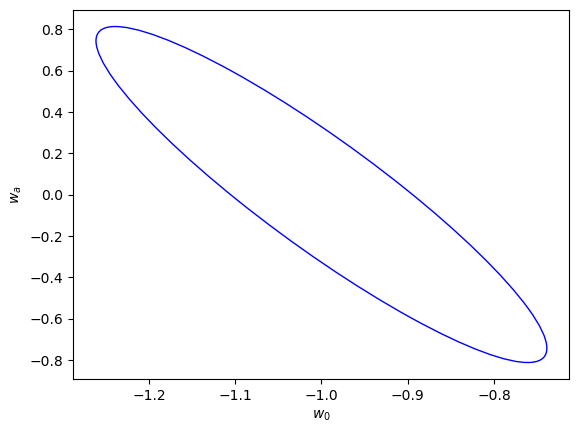

In [3]:
plot_params = ['w0', 'wa']
fig, ax = plt.subplots()

ax, xlim, ylim, mu, latex = fm.draw_covariance_ellipse(ax, parameters=plot_params, CL=0.393, color='b', fill=False, ls='-')

ax.set_xlim([mu[0] - 1.1 * xlim, mu[0] + 1.1 * xlim])
ax.set_ylim([mu[1] - 1.1 * ylim, mu[1] + 1.1 * ylim])

ax.set_xlabel(f'{latex[0]}')
ax.set_ylabel(f'{latex[1]}')


### Visualise all of the parameter spaace

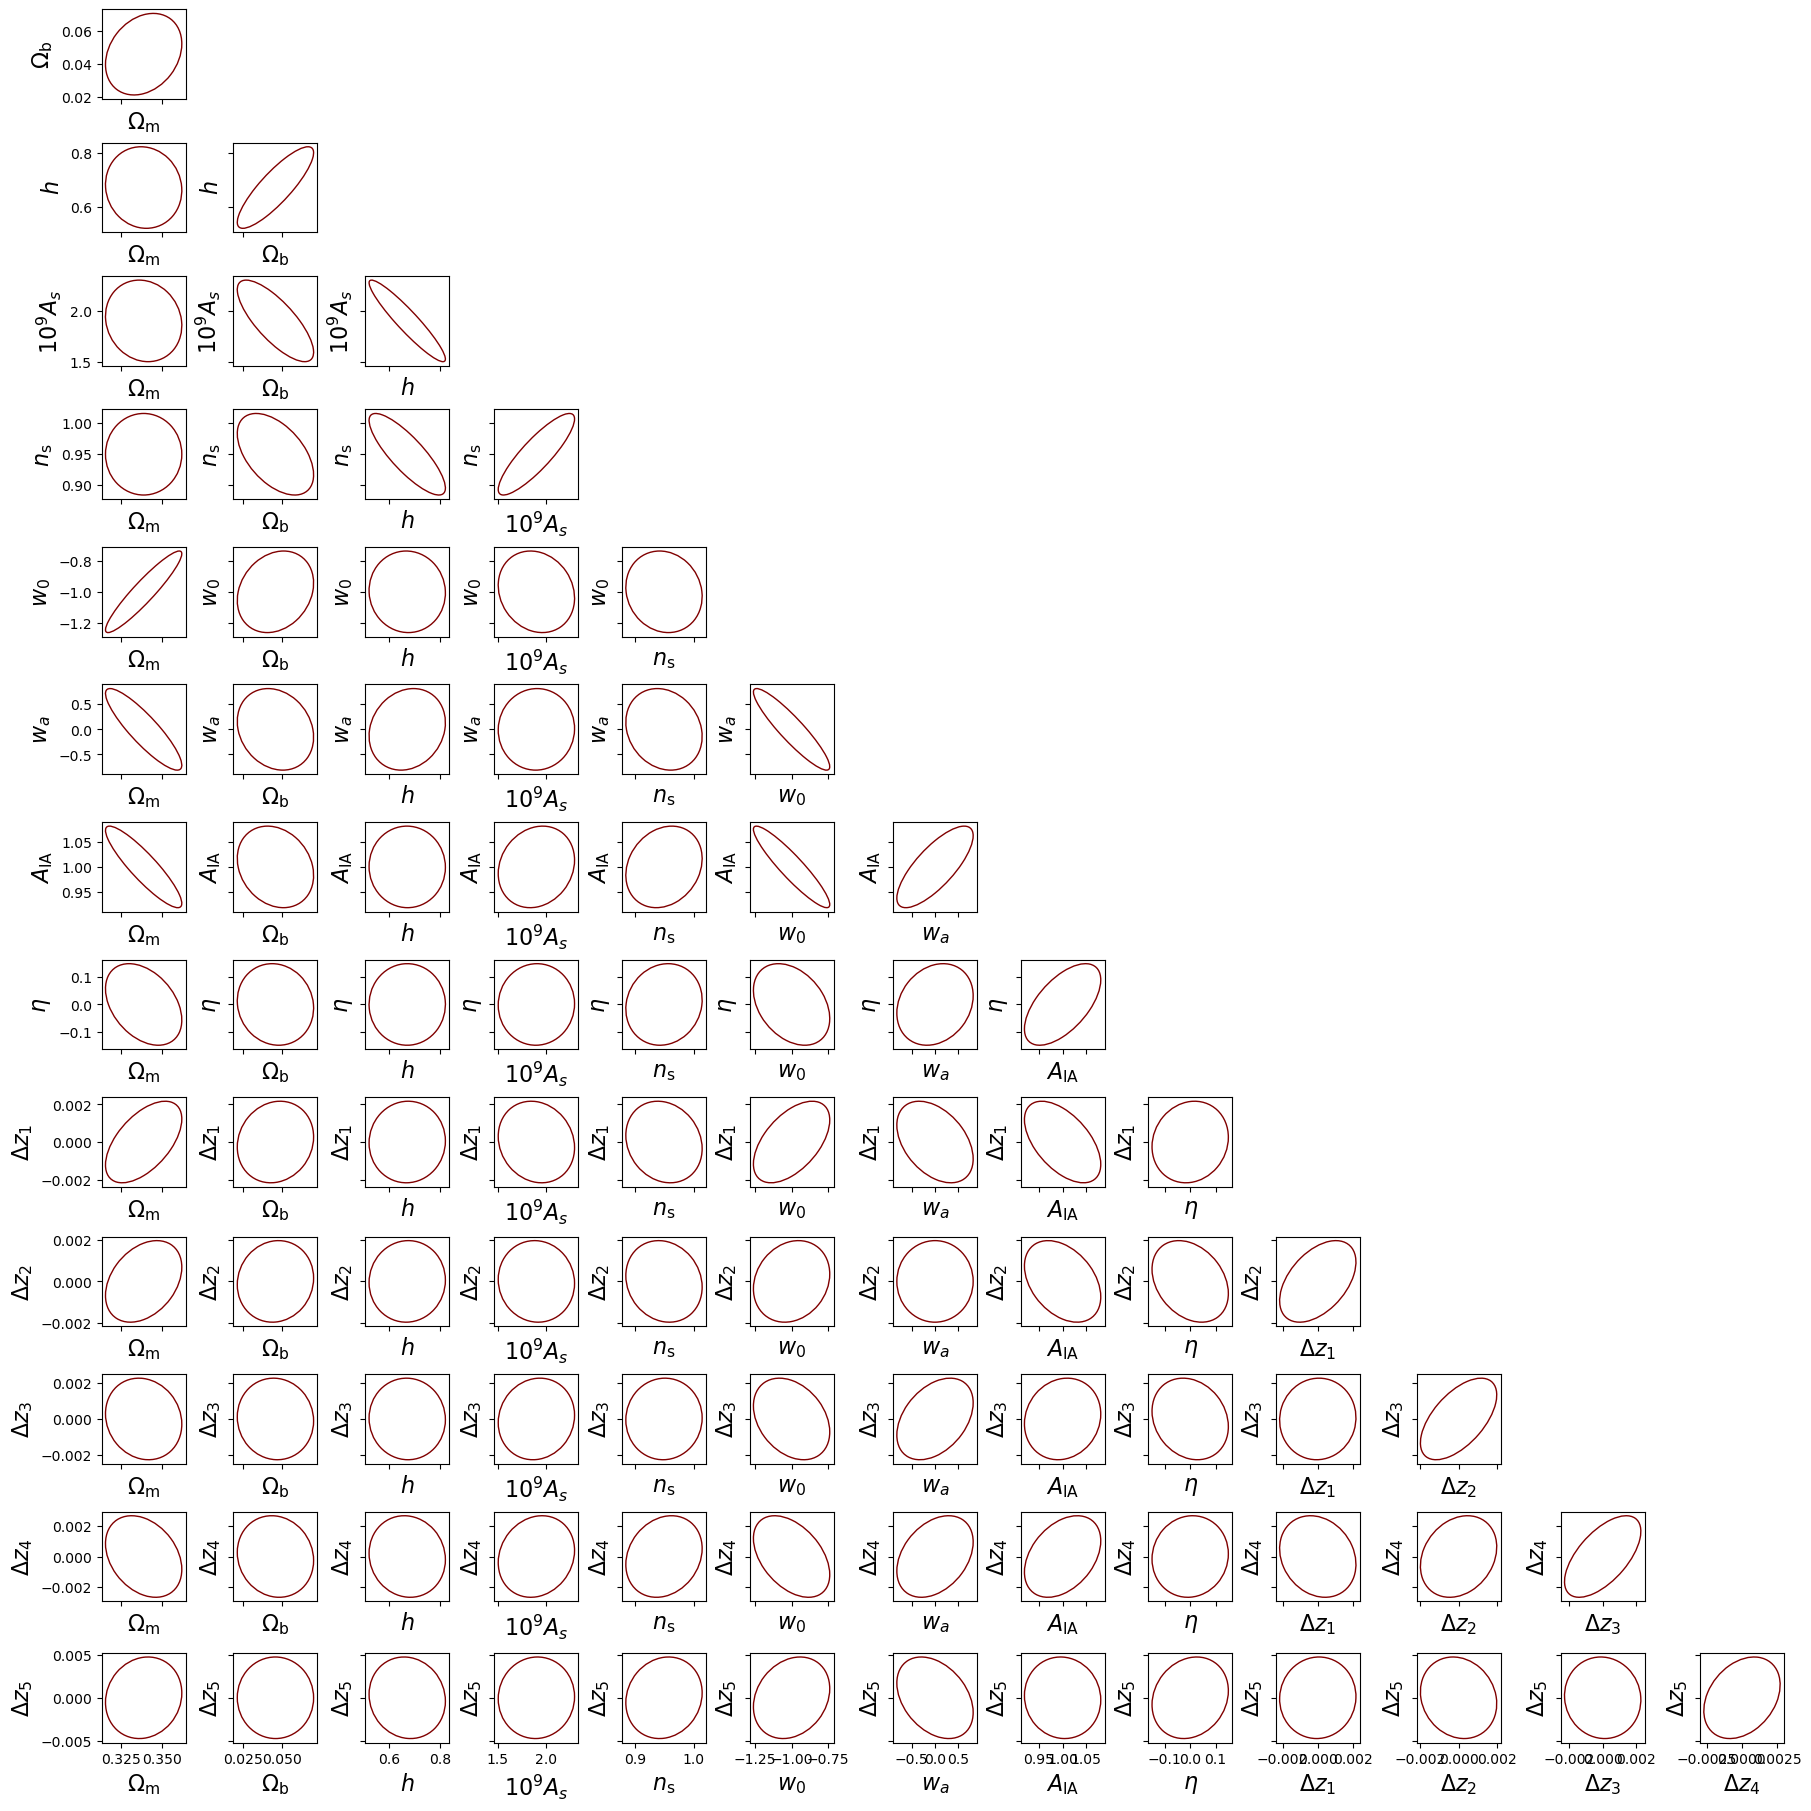

In [4]:
parameters = fm.parameters
fig, axes = plt.subplots(len(parameters)-1, len(parameters)-1, figsize=(18,18),
                         sharex='col', sharey='row', layout='compressed', squeeze=False)
for p2i, param2 in enumerate(parameters[1:]): # row
    for p1i, param1 in enumerate(parameters[:-1]): # column
        ax = axes[p2i, p1i]
        if p1i>p2i:
            fig.delaxes(ax)
            continue
        else:
            ax, xlim, ylim, mu, latex = fm.draw_covariance_ellipse(ax, [param1, param2],
                CL=0.393, color='maroon', fill=False, ls='-')
            
            ax.set_xlabel(f'{latex[0]}', fontsize=16)
            ax.set_xlim([mu[0]-1.1*xlim, mu[0]+1.1*xlim])
            
            ax.set_ylim([mu[1]-1.1*ylim, mu[1]+1.1*ylim])
            ax.set_ylabel(f'{latex[1]}', fontsize=16)

# Validate Fisher derivative step size

In [5]:
shifts, FoM_validation = IO.load_fisher_matrix_validation(config, 'validation_fisher_matrix')

Text(0.5, 0, 'shift')

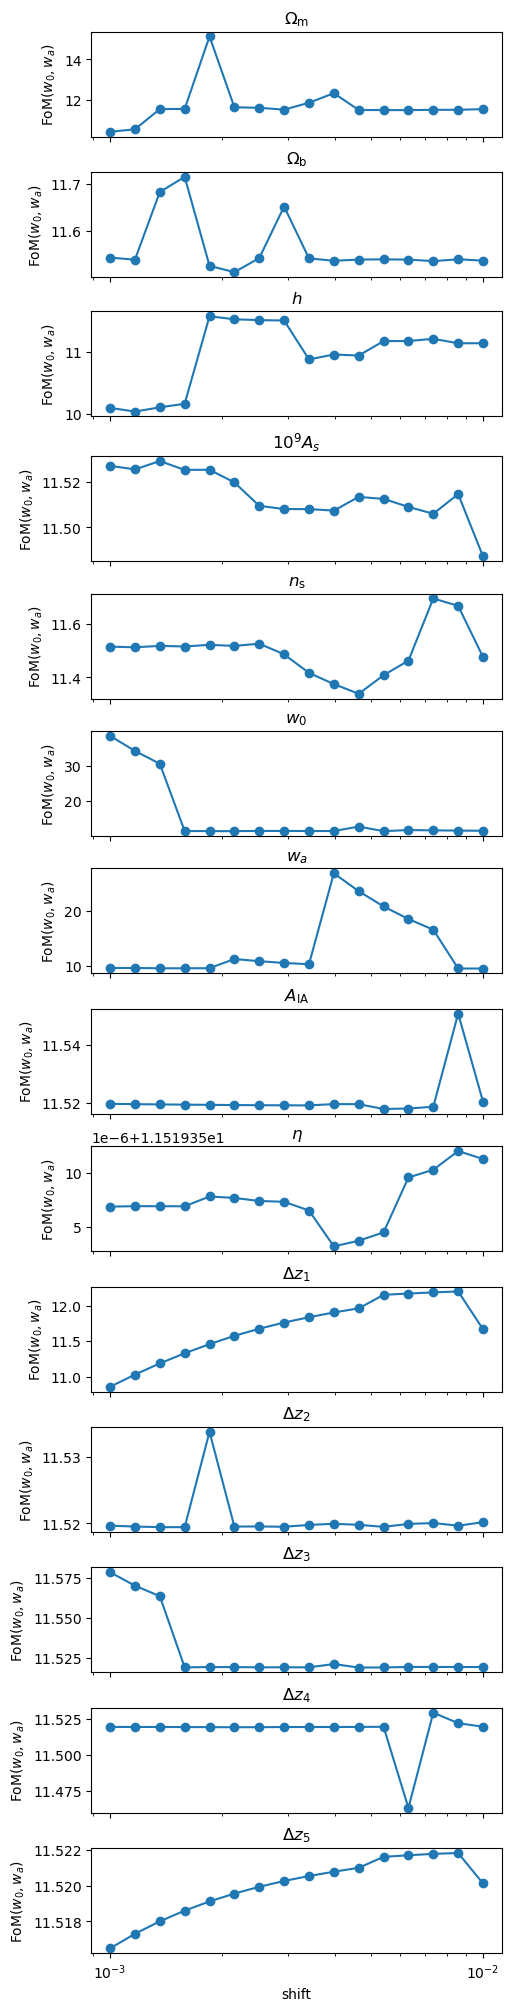

In [6]:
fig, ax = plt.subplots(len(fm.parameters), 1,
                         figsize=(5,20), layout='compressed', sharex='col')
for pi, p in enumerate(fm.parameters):
    m = FoM_validation[pi]>0
    ax[pi].plot(shifts[m], FoM_validation[pi][m], 'o-')
    ax[pi].set_ylabel(r'$\mathrm{FoM}(w_0,w_a)$')
    ax[pi].set_xscale('log')
    ax[pi].set_title(fm.latex_parameters[pi])
    #for param_dict in [fm.cosmo_params,
    #                   fm.astro_params,
    #                   fm.redshift_params]:
    #    if p in param_dict['name']:
    #        pi_where = np.in1d(param_dict['name'], p).nonzero()[0][0]
    #        ax[pi].axvline(x=param_dict['shift'][pi_where], ls='--', c='r')
ax[-1].set_xlabel('shift')